<a href="https://colab.research.google.com/github/omarbemo/Data_Analysis/blob/main/Heart_Failure_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [185]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "heart.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "fedesoriano/heart-failure-prediction",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

/tmp/ipykernel_21611/924683985.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'heart-failure-prediction' dataset.


In [186]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [187]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [188]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


**Data Preproessing and Outlier detection**

# AGE

In [189]:
df.Age.describe()

,Age
count,918.000000
mean,53.510893
std,9.432617
min,28.000000
25%,47.000000
50%,54.000000
75%,60.000000
max,77.000000


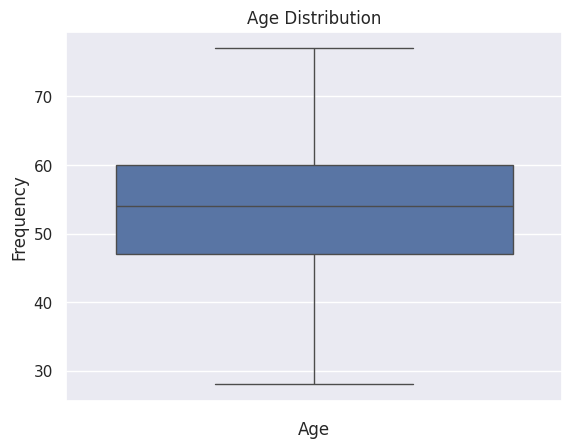

In [190]:
sns.boxplot(df.Age)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

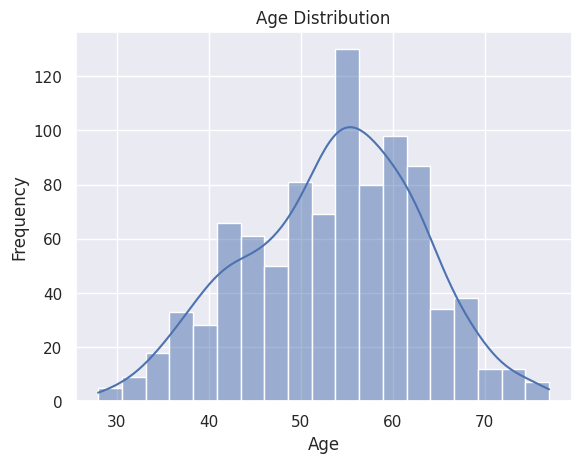

In [191]:
sns.histplot(df.Age , kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [192]:
Q1=df.Age.quantile(0.25)
Q3=df.Age.quantile(0.75)
IQR=Q3-Q1
print(IQR)
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
print(lower_limit)
print(upper_limit)
NewDf = df[(df.Age >= lower_limit) & (df.Age <= upper_limit)]
print(f'The data before removing the outliers is{df.shape}')
print(f'The data after removing the outliers is{NewDf.shape}')

13.0
27.5
79.5
The data before removing the outliers is(918, 12)
The data after removing the outliers is(918, 12)


# SEX

In [193]:
df[['Sex']].value_counts()

,count
Sex,
M,725
F,193


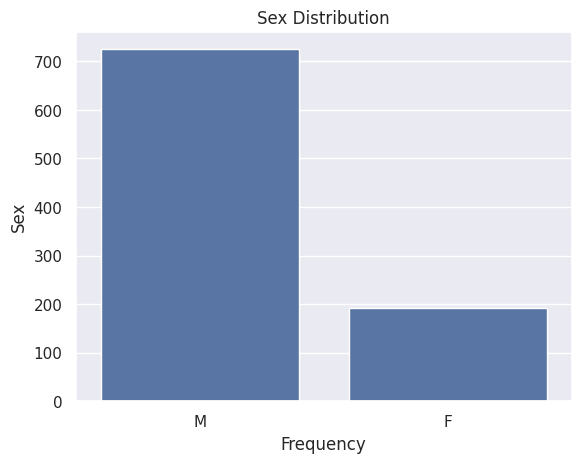

In [194]:
sns.countplot(x=df.Sex)
plt.title('Sex Distribution')
plt.xlabel('Frequency')
plt.ylabel('Sex')
sns.set_theme(style="darkgrid")
plt.show()

# ChestPainType

In [195]:
df[["ChestPainType"]].value_counts()

,count
ChestPainType,
ASY,496
NAP,203
ATA,173
TA,46


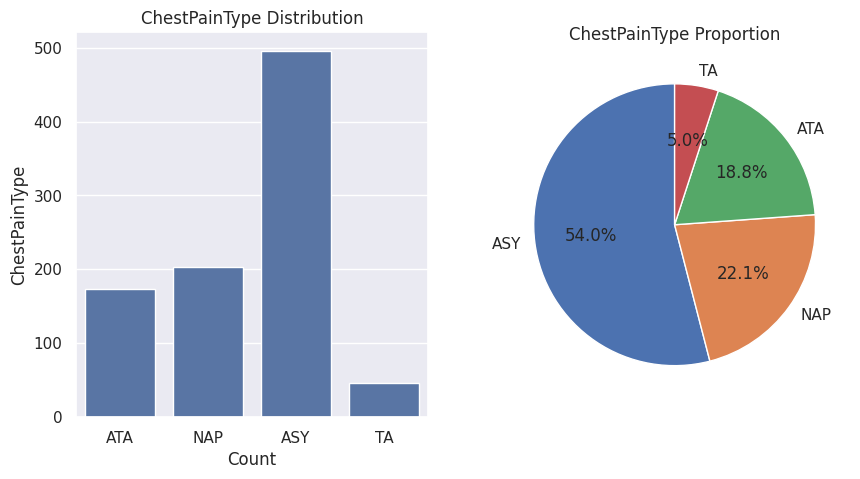

In [196]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.countplot(x=df.ChestPainType)
plt.title('ChestPainType Distribution')
plt.xlabel('Count')
plt.ylabel('ChestPainType')

plt.subplot(1,2,2)
chest_pain_counts = df['ChestPainType'].value_counts()
plt.pie(chest_pain_counts, labels=chest_pain_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('ChestPainType Proportion')
plt.show()

# RestingBP

In [197]:
df.RestingBP.describe()

,RestingBP
count,918.000000
mean,132.396514
std,18.514154
min,0.000000
25%,120.000000
50%,130.000000
75%,140.000000
max,200.000000


In [198]:
Q1 = df.RestingBP.quantile(0.25)
Q3 = df.RestingBP.quantile(0.75)
IQR = Q3 - Q1
print(IQR)
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print(lower_limit)
print(upper_limit)
NewDf = df[(df.RestingBP >= lower_limit) & (df.RestingBP <= upper_limit)]
print(f'The data before removing the outliers is{df.shape}')
print(f'The data after removing the outliers is{NewDf.shape}')


20.0
90.0
170.0
The data before removing the outliers is(918, 12)
The data after removing the outliers is(890, 12)


In [199]:
df[df['RestingBP'] < 90]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
314,53,M,ASY,80,0,0,Normal,141,Y,2.0,Down,0
449,55,M,NAP,0,0,0,Normal,155,N,1.5,Flat,1


We should drop row 449 due to inaccurate data but the outliers greater than the higher limit can't be removed as it may be accuarte data and means a dangerous state.

In [200]:
df.drop(index=449, inplace=True)


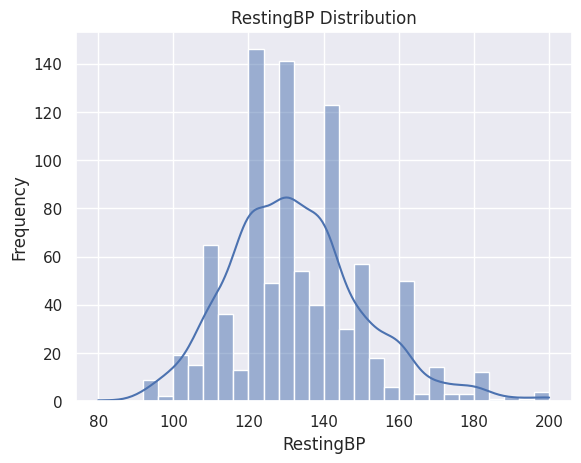

In [201]:
sns.histplot(df.RestingBP , kde=True)
plt.title('RestingBP Distribution')
plt.xlabel('RestingBP')
plt.ylabel('Frequency')
plt.show()

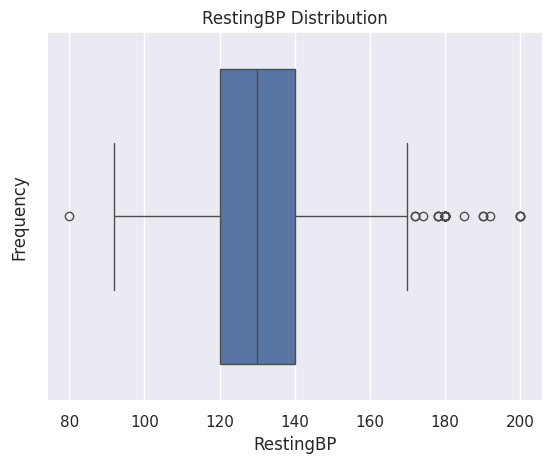

In [202]:
sns.boxplot(x=df.RestingBP)
plt.title('RestingBP Distribution')
plt.xlabel('RestingBP')
plt.ylabel('Frequency')
plt.show()

# Cholesterol

In [203]:
df[['Cholesterol']].describe()

,Cholesterol
count,917.000000
mean,199.016358
std,109.246330
min,0.000000
25%,174.000000
50%,223.000000
75%,267.000000
max,603.000000


In [204]:
Q1 = df.Cholesterol.quantile(0.25)
Q3 = df.Cholesterol.quantile(0.75)
IQR = Q3 - Q1
print(IQR)
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print(lower_limit)
print(upper_limit)
NewDf = df[(df.Cholesterol >= lower_limit) & (df.Cholesterol <= upper_limit)]
print(f'The data before removing the outliers is{df.shape}')
print(f'The data after removing the outliers is{NewDf.shape}')


93.0
34.5
406.5
The data before removing the outliers is(917, 12)
The data after removing the outliers is(734, 12)


In [205]:
df[df['Cholesterol']<34.5]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
293,65,M,ASY,115,0,0,Normal,93,Y,0.0,Flat,1
294,32,M,TA,95,0,1,Normal,127,N,0.7,Up,1
295,61,M,ASY,105,0,1,Normal,110,Y,1.5,Up,1
296,50,M,ASY,145,0,1,Normal,139,Y,0.7,Flat,1
297,57,M,ASY,110,0,1,ST,131,Y,1.4,Up,1
...,...,...,...,...,...,...,...,...,...,...,...,...
514,43,M,ASY,122,0,0,Normal,120,N,0.5,Up,1
515,63,M,NAP,130,0,1,ST,160,N,3.0,Flat,0
518,48,M,NAP,102,0,1,ST,110,Y,1.0,Down,1
535,56,M,ASY,130,0,0,LVH,122,Y,1.0,Flat,1


There is no way someone has Cholesterol equals to zero so this data must be romved

In [206]:
df = df[df['Cholesterol']!=0]

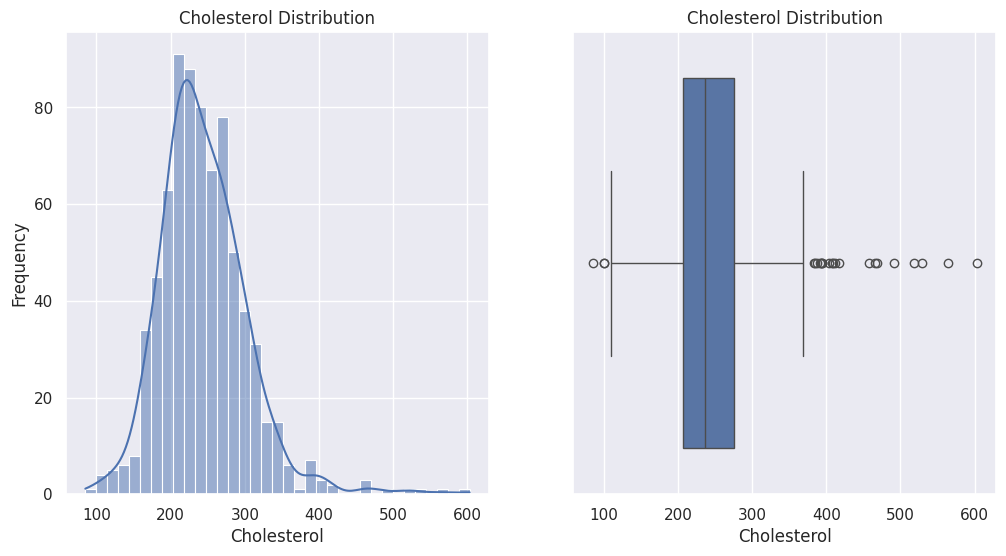

In [207]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.histplot(df.Cholesterol , kde=True)
plt.title('Cholesterol Distribution')
plt.xlabel('Cholesterol')
plt.ylabel('Frequency')
plt.subplot(1,2,2)

sns.boxplot(x=df.Cholesterol)
plt.title('Cholesterol Distribution')
plt.xlabel('Cholesterol')
plt.show()

These outliers can't be removed as they often represent patients with extreme, life-threatening conditions

# FastingBS

In [208]:
df.FastingBS.value_counts()

,count
FastingBS,
0,621
1,125


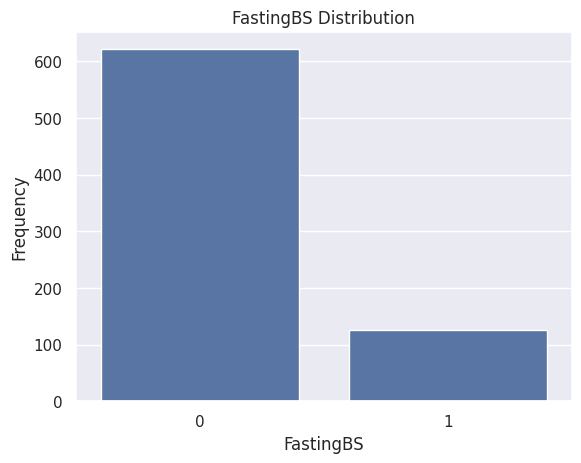

In [209]:
sns.countplot(x=df.FastingBS)
plt.title('FastingBS Distribution')
plt.xlabel('FastingBS')
plt.ylabel('Frequency')
plt.show()

#RestingECG

In [210]:
df[['RestingECG']].value_counts()

,count
RestingECG,
Normal,445
LVH,176
ST,125


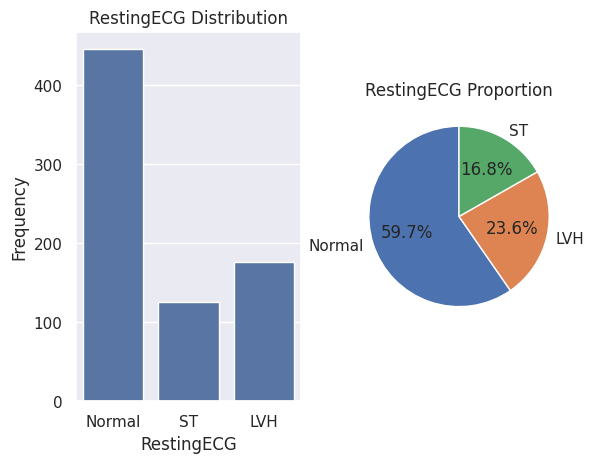

In [211]:
plt.subplot(1,2,1)
sns.countplot(x=df.RestingECG)
plt.title('RestingECG Distribution')
plt.xlabel('RestingECG')
plt.ylabel('Frequency')
plt.subplot(1,2,2)
ecg_counts = df['RestingECG'].value_counts()
plt.pie(ecg_counts, labels=ecg_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('RestingECG Proportion')
plt.show()

# MaxHR

In [212]:
df[['MaxHR']].describe()

,MaxHR
count,746.000000
mean,140.226542
std,24.524107
min,69.000000
25%,122.000000
50%,140.000000
75%,160.000000
max,202.000000


In [213]:
Q1 = df.MaxHR.quantile(0.25)
Q3 = df.MaxHR.quantile(0.75)
IQR = Q3 - Q1
print(IQR)
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print(lower_limit)
print(upper_limit)
NewDf = df[(df.MaxHR >= lower_limit) & (df.MaxHR <= upper_limit)]
print(f'The data before removing the outliers is{df.shape}')
print(f'The data after removing the outliers is{NewDf.shape}')


38.0
65.0
217.0
The data before removing the outliers is(746, 12)
The data after removing the outliers is(746, 12)


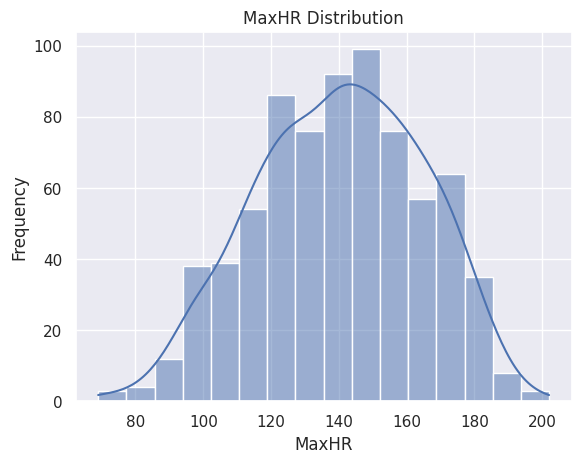

In [214]:
sns.histplot(df.MaxHR , kde=True)
plt.xlabel('MaxHR')
plt.ylabel('Frequency')
plt.title('MaxHR Distribution')
plt.show()

# ExerciseAngina

In [215]:
df[['ExerciseAngina']].value_counts()

,count
ExerciseAngina,
N,459
Y,287


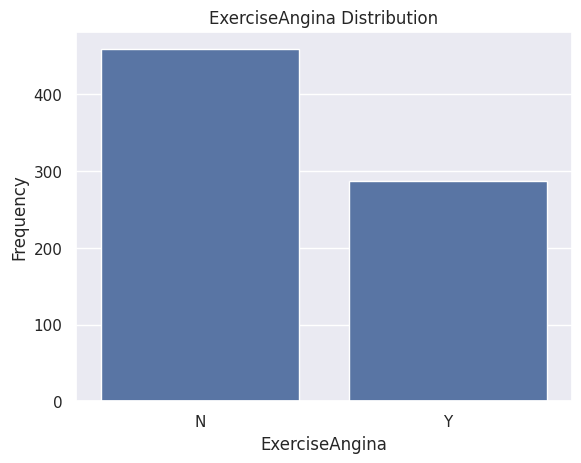

In [216]:
sns.countplot(x=df.ExerciseAngina)
plt.title('ExerciseAngina Distribution')
plt.xlabel('ExerciseAngina')
plt.ylabel('Frequency')
plt.show()


# Oldpeak

In [217]:
df[['Oldpeak']].describe()

,Oldpeak
count,746.000000
mean,0.901609
std,1.072861
min,-0.100000
25%,0.000000
50%,0.500000
75%,1.500000
max,6.200000


In [218]:
Q1 = df.Oldpeak.quantile(0.25)
Q3 = df.Oldpeak.quantile(0.75)
IQR = Q3 - Q1
print(IQR)
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print(lower_limit)
print(upper_limit)
NewDf = df[(df.Oldpeak >= lower_limit) & (df.Oldpeak <= upper_limit)]
print(f'The data before removing the outliers is{df.shape}')
print(f'The data after removing the outliers is{NewDf.shape}')

1.5
-2.25
3.75
The data before removing the outliers is(746, 12)
The data after removing the outliers is(731, 12)


Also here we cant remove the outliers as they are important to our case


#ST_Slope

In [219]:
df[['ST_Slope']].value_counts()

,count
ST_Slope,
Flat,354
Up,349
Down,43


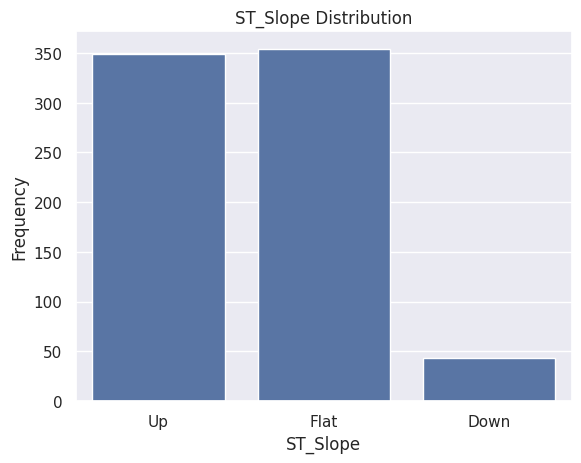

In [220]:
sns.countplot(x=df.ST_Slope)
plt.title('ST_Slope Distribution')
plt.xlabel('ST_Slope')
plt.ylabel('Frequency')
plt.show()

# HeartDisease

In [221]:
df[['HeartDisease']].value_counts()

,count
HeartDisease,
0,390
1,356


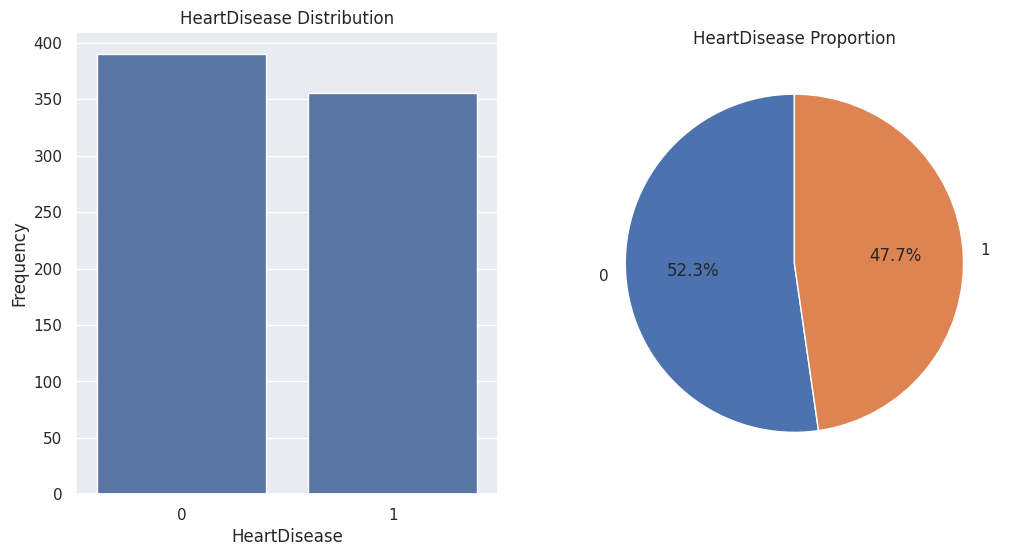

In [222]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.countplot(x=df.HeartDisease)
plt.title('HeartDisease Distribution')
plt.xlabel('HeartDisease')
plt.ylabel('Frequency')
plt.subplot(1,2,2)
heart_disease_counts = df['HeartDisease'].value_counts()
plt.pie(heart_disease_counts, labels=heart_disease_counts.index , autopct='%1.1f%%', startangle=90)
plt.title('HeartDisease Proportion')
plt.show()


In [223]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


**Now lets check the relationship between the columns**

# Age and (RestingBP, Cholesterol, MaxHR,Oldpeak, ST_Slope and HeartDisease)


In [224]:
age_bins = [20, 30, 40, 50, 60, 70, 80]
age_labels = ['20-30', '31-40', '41-50', '51-60', '61-70', '71-80']
df.loc[:, 'Age_Range'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=True)

display(df[['Age', 'Age_Range']].head())

/tmp/ipykernel_21611/2076033044.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Age_Range'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=True)


,Age,Age_Range
0,40,31-40
1,49,41-50
2,37,31-40
3,48,41-50
4,54,51-60


In [225]:
df.groupby('Age_Range', observed=False)[['RestingBP',"Cholesterol","MaxHR","Oldpeak"]].agg(['mean','median','std'])

RestingBP                   Cholesterol                    \
                 mean median        std        mean median        std   
Age_Range                                                               
20-30      138.000000  130.0  19.235384  215.800000  237.0  51.426647   
31-40      125.184211  120.0  16.083706  239.223684  223.0  68.001490   
41-50      128.736318  130.0  15.307029  239.631841  236.0  50.149115   
51-60      134.802632  131.5  17.588265  247.036184  236.0  61.841984   
61-70      138.764286  140.0  16.939847  253.242857  252.0  59.521095   
71-80      137.400000  140.0  18.802016  225.950000  221.0  58.358669   

                MaxHR                     Oldpeak                   
                 mean median        std      mean median       std  
Age_Range                                                           
20-30      177.400000  170.0  16.395121  0.000000   0.00  0.000000  
31-40      156.592105  159.0  23.897658  0.467105   0.00  0.883386  
41-50      146.452736  148.0  23.034301  0.622388   0.00  0.929971  
51-60      137.500000  140.0  23.201798  0.970066   0.80  1.054642  
61-70      129.928571  132.0  22.236674  1.359286   1.30  1.178580  
71-80      119.700000  115.5  17.183529  1.340000   1.45  1.197541

In [226]:
df.groupby('Age_Range', observed=False)[['HeartDisease']].value_counts()

Age_Range  HeartDisease
20-30      0                 5
           1                 0
31-40      0                55
           1                21
41-50      0               128
           1                73
51-60      1               154
           0               150
61-70      1                94
           0                46
71-80      1                14
           0                 6
Name: count, dtype: int64

### Age vs RestingBP

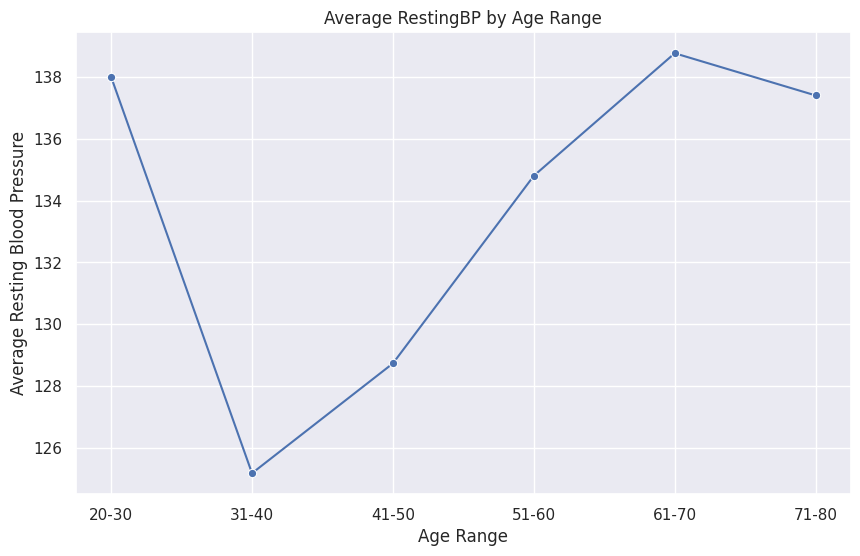

In [227]:
restingbp_mean_by_age = df.groupby('Age_Range', observed=False)['RestingBP'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(x='Age_Range', y='RestingBP', data=restingbp_mean_by_age, marker='o')
plt.title('Average RestingBP by Age Range')
plt.xlabel('Age Range')
plt.ylabel('Average Resting Blood Pressure')
plt.grid(True)
plt.show()

### Age vs Cholesterol

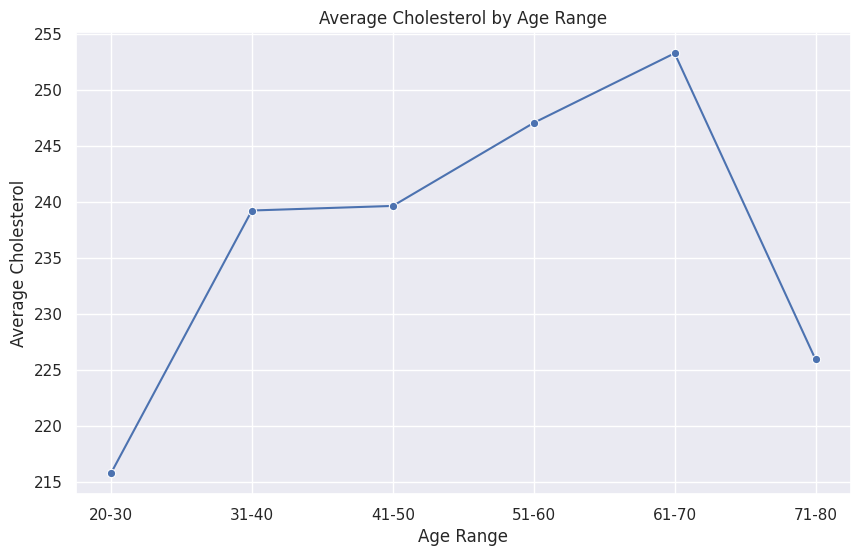

In [228]:
cholesterol_mean_by_age = df.groupby('Age_Range', observed=False)['Cholesterol'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(x='Age_Range', y='Cholesterol', data=cholesterol_mean_by_age, marker='o')
plt.title('Average Cholesterol by Age Range')
plt.xlabel('Age Range')
plt.ylabel('Average Cholesterol')
plt.grid(True)
plt.show()

### Age vs MaxHR

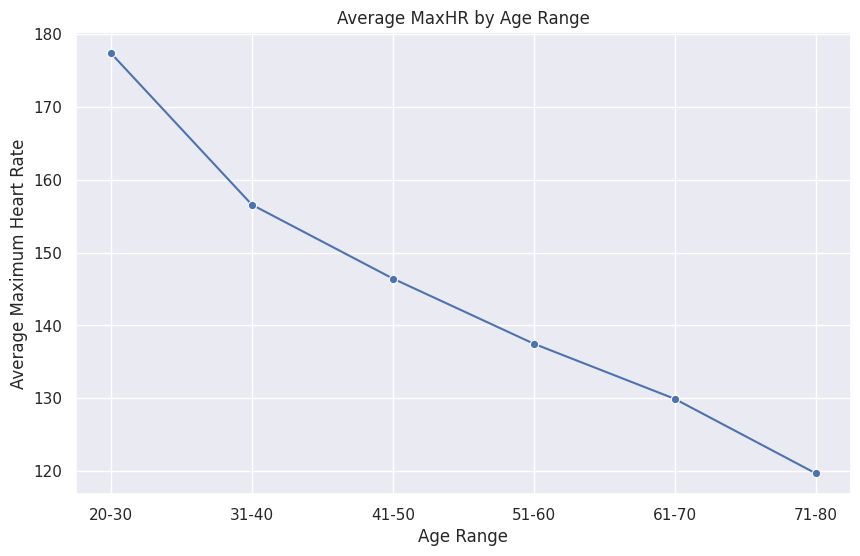

In [229]:
maxhr_mean_by_age = df.groupby('Age_Range', observed=False)['MaxHR'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(x='Age_Range', y='MaxHR', data=maxhr_mean_by_age, marker='o')
plt.title('Average MaxHR by Age Range')
plt.xlabel('Age Range')
plt.ylabel('Average Maximum Heart Rate')
plt.grid(True)
plt.show()

### Age vs Oldpeak

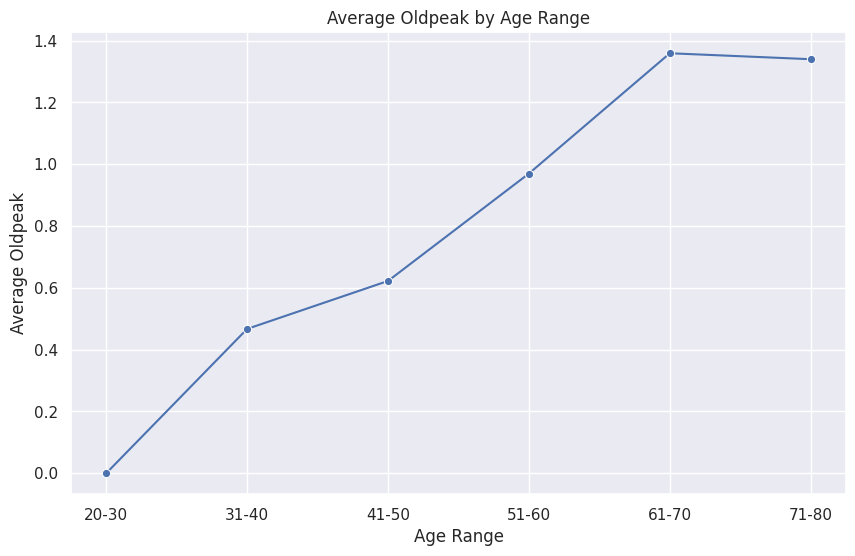

In [230]:
oldpeak_mean_by_age = df.groupby('Age_Range', observed=False)['Oldpeak'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(x='Age_Range', y='Oldpeak', data=oldpeak_mean_by_age, marker='o')
plt.title('Average Oldpeak by Age Range')
plt.xlabel('Age Range')
plt.ylabel('Average Oldpeak')
plt.grid(True)
plt.show()

### Age vs ST_Slope

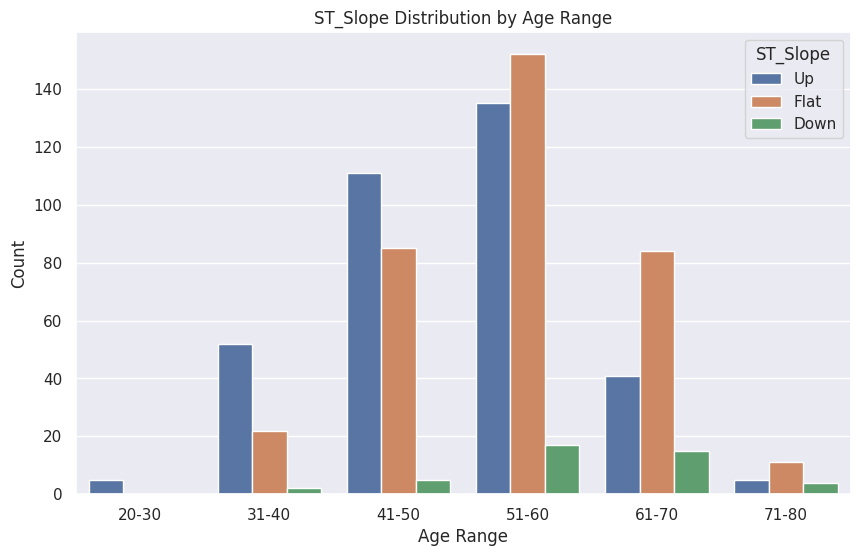

In [231]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Age_Range', hue='ST_Slope', data=df)
plt.title('ST_Slope Distribution by Age Range')
plt.xlabel('Age Range')
plt.ylabel('Count')
plt.legend(title='ST_Slope')
plt.show()

### Age vs HeartDisease

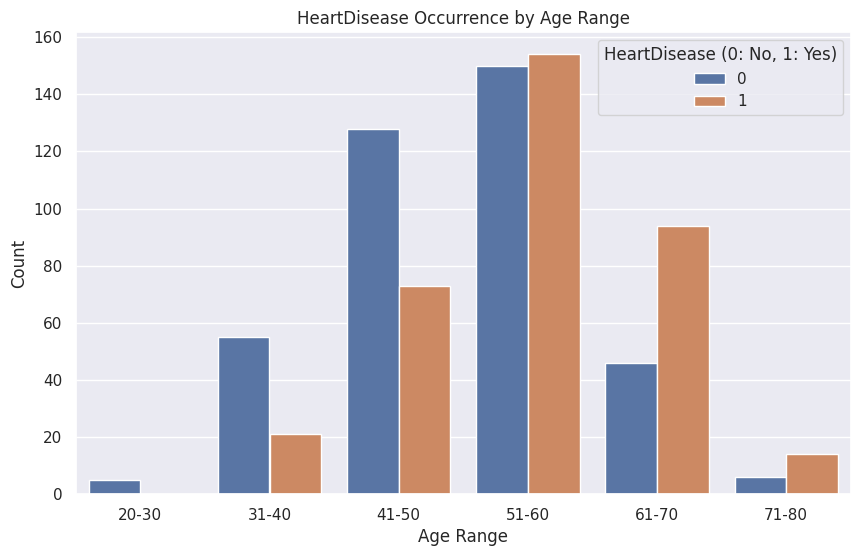

In [232]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Age_Range', hue='HeartDisease', data=df)
plt.title('HeartDisease Occurrence by Age Range')
plt.xlabel('Age Range')
plt.ylabel('Count')
plt.legend(title='HeartDisease (0: No, 1: Yes)')
plt.show()

## Sex and other features (RestingBP, Cholesterol, MaxHR, Oldpeak, ST_Slope and HeartDisease)

In [233]:
df.groupby('Sex', observed=False)[['RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']].agg(['mean', 'median', 'std'])

RestingBP                   Cholesterol                        MaxHR  \
           mean median        std        mean median        std       mean   
Sex                                                                          
F    131.978022  130.0  18.591258  255.774725  248.0  62.850070  147.00000   
M    133.359929  130.0  16.842386  241.040780  234.0  57.509194  138.04078   

                        Oldpeak                   
    median        std      mean median       std  
Sex                                               
F    150.0  21.963556  0.664286    0.0  0.959506  
M    139.5  24.922903  0.978191    0.8  1.096840

In [234]:
df.groupby('Sex', observed=False)[['HeartDisease']].value_counts()

Sex  HeartDisease
F    0               142
     1                40
M    1               316
     0               248
Name: count, dtype: int64

### Sex vs RestingBP

/tmp/ipykernel_21611/3565862447.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='RestingBP', data=df, estimator='mean', palette='viridis')


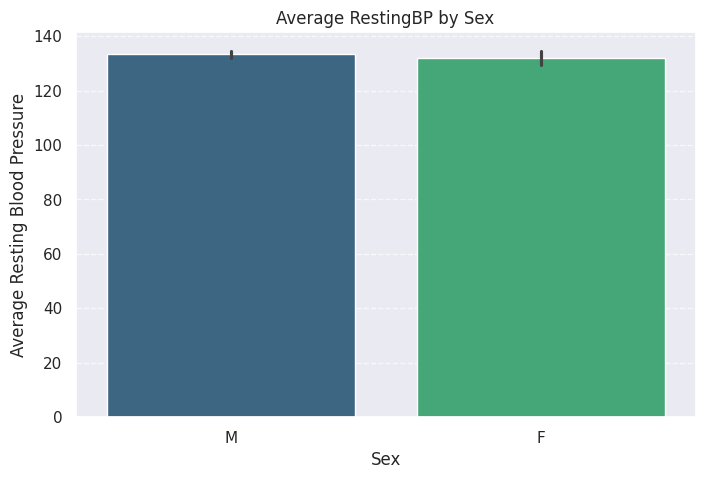

In [235]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Sex', y='RestingBP', data=df, estimator='mean', palette='viridis')
plt.title('Average RestingBP by Sex')
plt.xlabel('Sex')
plt.ylabel('Average Resting Blood Pressure')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Sex vs Cholesterol

/tmp/ipykernel_21611/3918141453.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Cholesterol', data=df, estimator='mean', palette='plasma')


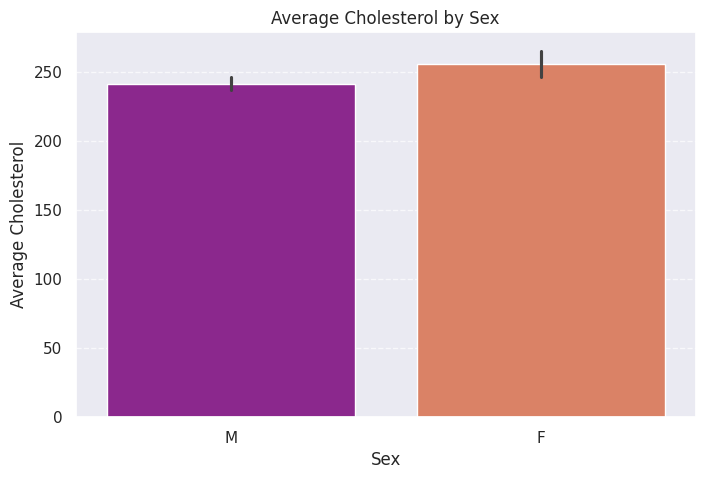

In [236]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Sex', y='Cholesterol', data=df, estimator='mean', palette='plasma')
plt.title('Average Cholesterol by Sex')
plt.xlabel('Sex')
plt.ylabel('Average Cholesterol')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Sex vs MaxHR

/tmp/ipykernel_21611/424283334.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='MaxHR', data=df, estimator='mean', palette='cividis')


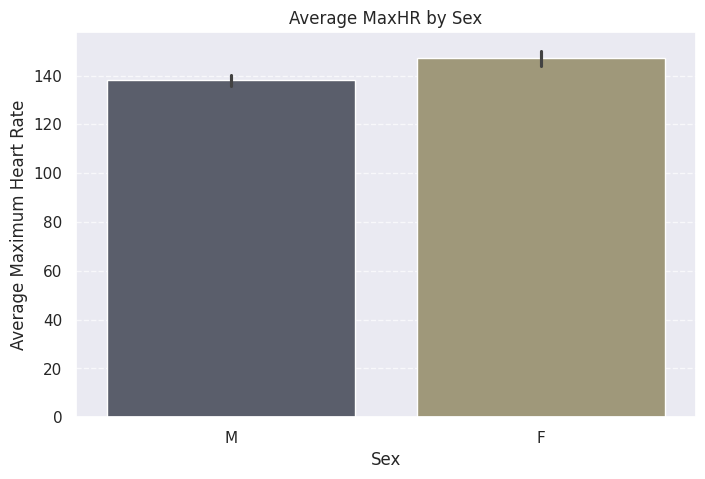

In [237]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Sex', y='MaxHR', data=df, estimator='mean', palette='cividis')
plt.title('Average MaxHR by Sex')
plt.xlabel('Sex')
plt.ylabel('Average Maximum Heart Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Sex vs Oldpeak

/tmp/ipykernel_21611/4292288281.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Oldpeak', data=df, estimator='mean', palette='magma')


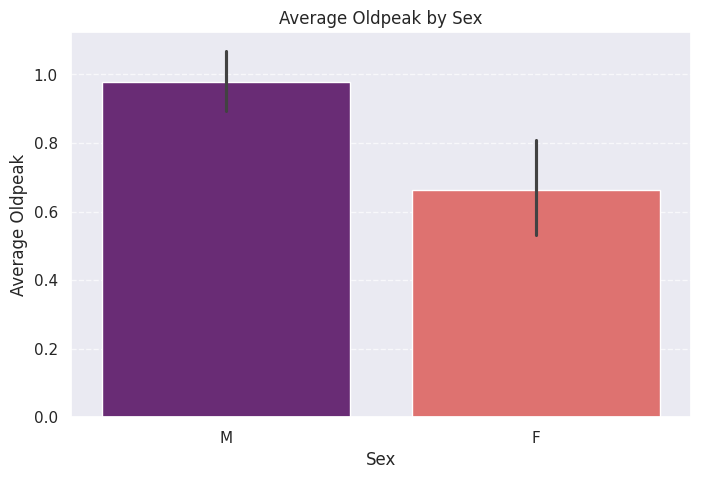

In [238]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Sex', y='Oldpeak', data=df, estimator='mean', palette='magma')
plt.title('Average Oldpeak by Sex')
plt.xlabel('Sex')
plt.ylabel('Average Oldpeak')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Sex vs ST_Slope

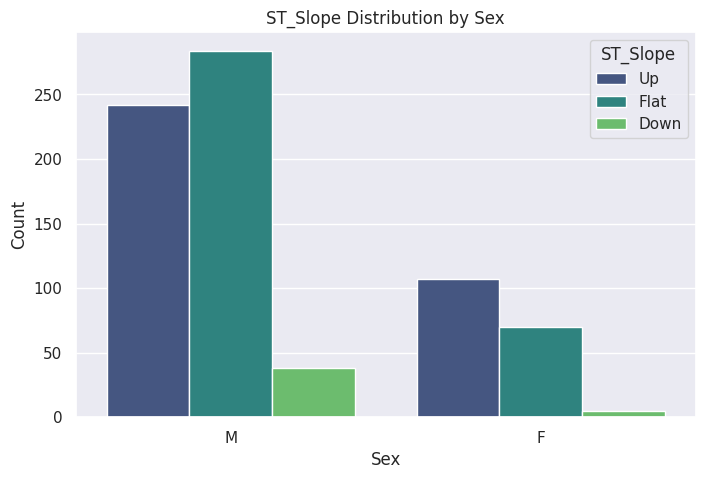

In [239]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Sex', hue='ST_Slope', data=df, palette='viridis')
plt.title('ST_Slope Distribution by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(title='ST_Slope')
plt.show()

### Sex vs HeartDisease

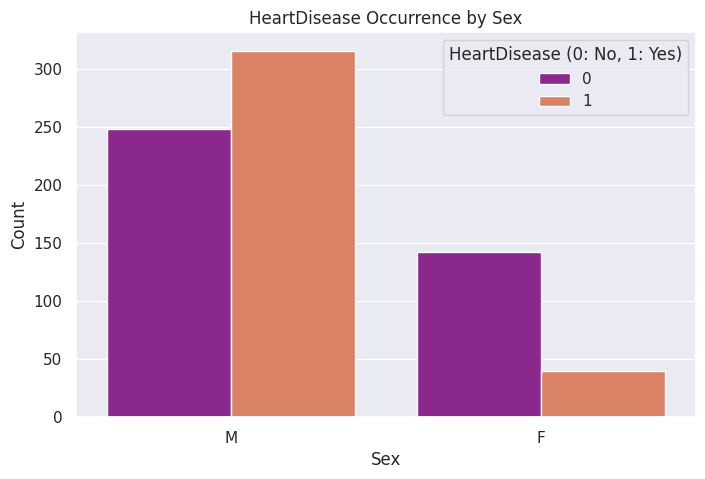

In [240]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Sex', hue='HeartDisease', data=df, palette='plasma')
plt.title('HeartDisease Occurrence by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(title='HeartDisease (0: No, 1: Yes)')
plt.show()

## Conclusion

## ChestPainType and HeartDisease

In [241]:
df.groupby('ChestPainType', observed=False)['HeartDisease'].value_counts().unstack()

HeartDisease,0,1
ChestPainType,,
ASY,96,274
ATA,145,21
NAP,123,46
TA,26,15


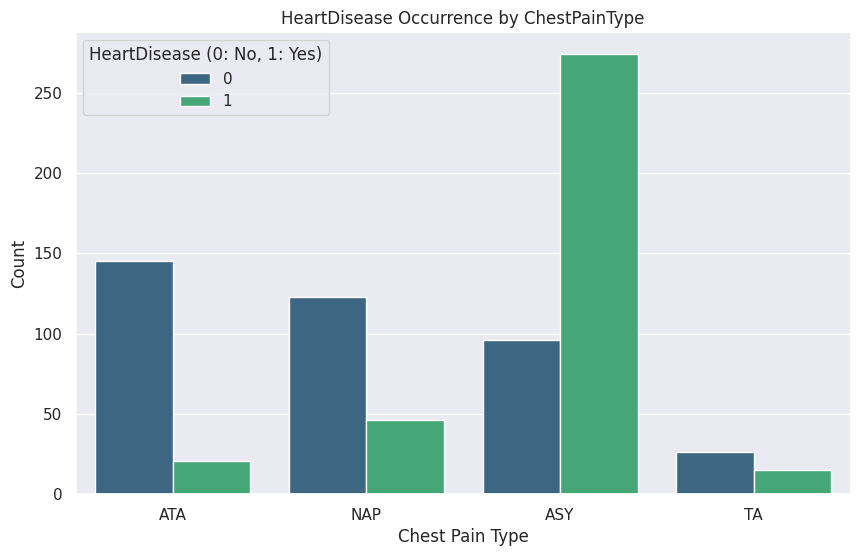

In [242]:
plt.figure(figsize=(10, 6))
sns.countplot(x='ChestPainType', hue='HeartDisease', data=df, palette='viridis')
plt.title('HeartDisease Occurrence by ChestPainType')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.legend(title='HeartDisease (0: No, 1: Yes)')
plt.show()

### ChestPainType Insights:
*   **ASY (Asymptomatic)**: This type of chest pain shows the highest count of HeartDisease (1).
*   **ATA (Typical Angina)**: This type has a lower count of HeartDisease (1) compared to ASY, and a higher count of no HeartDisease (0).
*   **NAP (Non-Anginal Pain)**: Similar to ATA, NAP also has a lower count of HeartDisease (1) compared to ASY.
*   **TA (Typical Angina)**: This type shows a relatively balanced distribution between HeartDisease (1) and no HeartDisease (0), but with much smaller overall counts.

This suggests that 'ASY' chest pain type is strongly associated with the presence of heart disease in this dataset, while 'ATA' and 'NAP' are more associated with no heart disease.

Based on our analysis:

### Age-Range Insights:
*   **RestingBP**: Generally shows an increase in average resting blood pressure with age, peaking around 61-70 years old.
*   **Cholesterol**: Average cholesterol levels tend to be higher in older age groups, particularly in the 61-70 range.
*   **MaxHR**: Maximum heart rate generally decreases with increasing age.
*   **Oldpeak**: The average 'Oldpeak' value, an indicator of exercise-induced ST depression, tends to increase with age, suggesting more severe heart conditions in older individuals.
*   **ST_Slope**: 'Flat' and 'Up' ST_Slope types are prominent across all age ranges, but there's a noticeable increase in 'Flat' and 'Down' slopes in older age groups, which can be indicative of ischemia.
*   **HeartDisease**: The count of individuals with heart disease significantly increases in older age ranges, with the highest counts observed in the 51-60 and 61-70 age groups.

### Sex Insights:
*   **RestingBP**: The average resting blood pressure is slightly higher in males (approx. 133.36 mmHg) compared to females (approx. 131.98 mmHg).
*   **Cholesterol**: Females have a higher average cholesterol level (approx. 255.77 mg/dL) compared to males (approx. 241.04 mg/dL).
*   **MaxHR**: Females tend to have a higher average maximum heart rate (approx. 147.00 bpm) than males (approx. 138.04 bpm).
*   **Oldpeak**: Males show a higher average 'Oldpeak' value (approx. 0.98) compared to females (approx. 0.66), suggesting potentially more significant exercise-induced ST depression in males.
*   **ST_Slope**: Males show a higher count of 'Flat' and 'Up' ST_Slope types, while females have fewer 'Down' slopes. The distribution across ST_Slope types differs between sexes.
*   **HeartDisease**: There are significantly more males with heart disease (316) than females (40) in this dataset, and also more males without heart disease (248) than females without heart disease (142). This indicates a higher prevalence of heart disease among males in this cohort.

This analysis highlights distinct patterns and differences in heart disease indicators and prevalence across different age ranges and sexes, which are crucial for understanding and predicting heart disease risk.

## ChestPainType Insights by Age Range and Sex

In [243]:
chestpain_by_age_sex = df.groupby(['Age_Range', 'Sex', 'ChestPainType'], observed=False).size().unstack(fill_value=0)
display(chestpain_by_age_sex)

# To find the most common chest pain type for each Age_Range and Sex combination
most_common_chestpain = chestpain_by_age_sex.idxmax(axis=1)
print("\nMost Common ChestPainType for each Age_Range and Sex combination:")
display(most_common_chestpain)

ChestPainType  ASY  ATA  NAP  TA
Age_Range Sex                   
20-30     F      0    0    0   1
          M      0    4    0   0
31-40     F      5    6    5   1
          M     19   19   17   4
41-50     F     15   25   16   1
          M     77   32   30   5
51-60     F     23   24   19   3
          M    133   43   49  10
61-70     F     18    2   10   3
          M     69    9   17  12
71-80     F      1    2    2   0
          M     10    0    4   1


Most Common ChestPainType for each Age_Range and Sex combination:


Age_Range  Sex
20-30      F       TA
           M      ATA
31-40      F      ATA
           M      ASY
41-50      F      ATA
           M      ASY
51-60      F      ATA
           M      ASY
61-70      F      ASY
           M      ASY
71-80      F      ATA
           M      ASY
dtype: object

### Detailed ChestPainType Insights by Age Range and Sex:

Based on the analysis of `ChestPainType` across different `Age_Range` and `Sex` categories, here are some insights:

*   **General Trend**: 'ASY' (Asymptomatic) chest pain is a very prevalent type across most age ranges and both sexes, often appearing as the most common.

*   **Age-Specific Patterns**:
    *   **Younger Age Groups (20-30, 31-40)**: In these groups, 'ATA' (Typical Angina) and 'NAP' (Non-Anginal Pain) also show significant counts, sometimes rivaling or exceeding 'ASY' depending on the sex.
    *   **Middle to Older Age Groups (41-50, 51-60, 61-70, 71-80)**: 'ASY' tends to become increasingly dominant, especially for males, suggesting that as individuals age, asymptomatic chest pain becomes a more prominent characteristic among those experiencing chest discomfort.

*   **Sex-Specific Patterns**:
    *   **Males**: Across most age ranges, males frequently exhibit 'ASY' as their most common chest pain type. 'NAP' and 'ATA' are also present but 'ASY' often dominates.
    *   **Females**: While 'ASY' is common, 'NAP' and 'ATA' can sometimes be more prevalent than 'ASY' in certain younger female age groups. As females age, 'ASY' also tends to become more pronounced.

*   **Rarity**: 'TA' (Typical Angina) remains the least frequent chest pain type across almost all age and sex combinations, highlighting its relative rarity compared to other types.

These insights can guide further investigations into the underlying causes and implications of specific chest pain types within targeted demographic groups.

**After doing the EDA and data Preprocessing its is time for the Prediction model
And the model we are using is the Random Forest Classifier**

In [244]:
df = pd.get_dummies(df, columns=['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'])

In [250]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
x = df.drop(columns=['HeartDisease', 'Age_Range'], axis=1)
y = df['HeartDisease']
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)
model.fit(x_train, y_train)
y_predict = model.predict(x_test)
print(model.score(x_train, y_train))
print(model.score(x_test, y_test))

1.0
0.9066666666666666


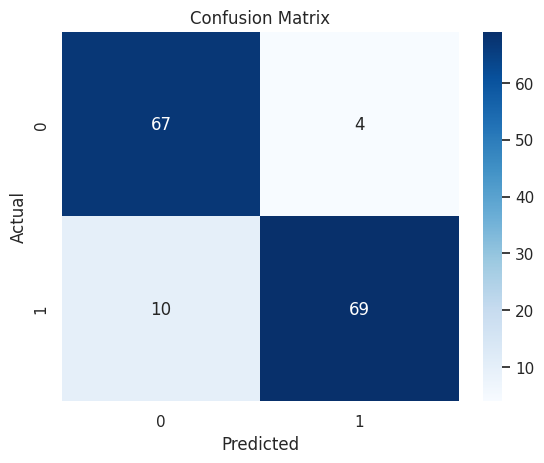

In [251]:
cm = confusion_matrix(y_test, y_predict)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [252]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.87      0.94      0.91        71
           1       0.95      0.87      0.91        79

    accuracy                           0.91       150
   macro avg       0.91      0.91      0.91       150
weighted avg       0.91      0.91      0.91       150



### Confusion Matrix Insights:
*   **True Negatives (67)**: The model correctly predicted no heart disease for 67 patients.
*   **True Positives (69)**: The model correctly identified heart disease in 69 patients.
*   **False Positives (4)**: The model incorrectly predicted heart disease for 4 patients (Type I error).
*   **False Negatives (10)**: The model incorrectly predicted no heart disease for 10 patients who actually had it (Type II error). Minimizing false negatives is often critical in medical diagnoses.

### Classification Report Insights:
*   **Accuracy (0.91)**: The overall proportion of correct predictions is 91%. This is a good general measure of performance.
*   **Precision for Heart Disease (Class 1: 0.95)**: When the model predicts a patient has heart disease, it's correct 95% of the time.
*   **Recall for Heart Disease (Class 1: 0.87)**: The model successfully identified 87% of all actual heart disease cases. This means 13% of actual heart disease cases were missed (the false negatives).
*   **F1-Score (0.91 for both classes)**: This is the harmonic mean of precision and recall, providing a balanced measure of the model's performance on both classes. A high F1-score indicates a good balance between catching positive cases and not incorrectly labeling negative ones.